In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("cleaned_and_updated_apple_products_pricing.csv")

In [3]:
df["Date"] =pd.to_datetime(df["Date"])

In [4]:
df.head()

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count,Year,Month,Month_Name,Quarter,Day,Day_Name
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.41,0.0,No_Sale_Event,In Stock,4.7,40,2020,9,September,3,19,Saturday
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.43,0.0,No_Sale_Event,Out of Stock,4.6,84,2020,9,September,3,20,Sunday
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.36,1.5,No_Sale_Event,In Stock,4.4,110,2020,9,September,3,23,Wednesday
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.70,0.9,No_Sale_Event,In Stock,4.8,111,2020,9,September,3,23,Wednesday
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.28,0.0,No_Sale_Event,In Stock,4.7,35,2020,9,September,3,24,Thursday


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               80000 non-null  datetime64[ns]
 1   Platform           80000 non-null  object        
 2   Product_Category   80000 non-null  object        
 3   Model_Name         80000 non-null  object        
 4   Condition          80000 non-null  object        
 5   Launch_Price_USD   80000 non-null  int64         
 6   Launch_Price_INR   80000 non-null  int64         
 7   Current_Price_USD  80000 non-null  float64       
 8   Current_Price_INR  80000 non-null  float64       
 9   Discount_Pct       80000 non-null  float64       
 10  Sale_Event         80000 non-null  object        
 11  Stock_Status       80000 non-null  object        
 12  Rating             80000 non-null  float64       
 13  Reviews_Count      80000 non-null  int64         
 14  Year  

In [6]:
df.shape

(80000, 20)

In [7]:
df.isnull().sum()

Date                 0
Platform             0
Product_Category     0
Model_Name           0
Condition            0
Launch_Price_USD     0
Launch_Price_INR     0
Current_Price_USD    0
Current_Price_INR    0
Discount_Pct         0
Sale_Event           0
Stock_Status         0
Rating               0
Reviews_Count        0
Year                 0
Month                0
Month_Name           0
Quarter              0
Day                  0
Day_Name             0
dtype: int64

### Summary statistics

In [8]:
df[["Launch_Price_USD","Launch_Price_INR","Current_Price_USD"]].describe()

,Launch_Price_USD,Launch_Price_INR,Current_Price_USD
count,80000.000000,80000.000000,80000.000000
mean,963.959125,94467.994250,782.769855
std,470.086413,46068.468464,461.673970
min,329.000000,32242.000000,109.930000
25%,599.000000,58702.000000,432.930000
50%,799.000000,78302.000000,699.740000
75%,1199.000000,117502.000000,989.112500
max,1999.000000,195902.000000,2038.970000


In [9]:
import matplotlib.pyplot as plt

#### Launch Price (USD)

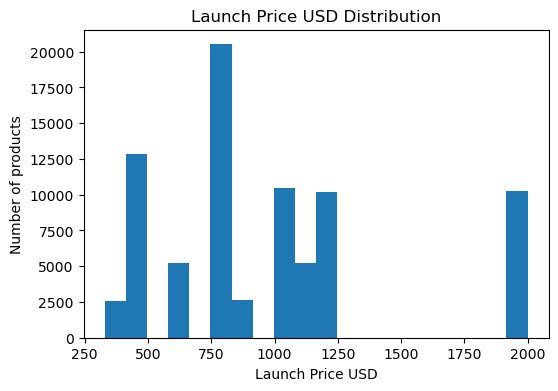

In [10]:
plt.figure(figsize = (6,4))
plt.hist(df["Launch_Price_USD"],bins = 20)
plt.title("Launch Price USD Distribution")
plt.xlabel("Launch Price USD")
plt.ylabel("Number of products")
plt.show()

### Observation
- Most products have a launch price between 400 and 1200
- A small number of premium products are priced around $2000
- The distribution indicates that Apple offers products across budget , mid-range, and premium price segments.
- There is a high launch price is 750

#### Launch Price (INR)

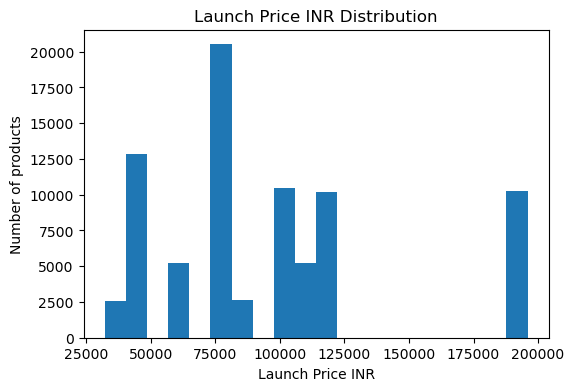

In [11]:
plt.figure(figsize = (6,4))
plt.hist(df["Launch_Price_INR"],bins = 20)
plt.title("Launch Price INR Distribution")
plt.xlabel("Launch Price INR")
plt.ylabel("Number of products")
plt.show()

#### Observation
- Most products have high a launch price between 40,000 and 1,20,000
- A fewer premium products are priced close to 2,00,000
- The INR distribution has the same shape as the USD because it is obtained by converting USD prices using a fixed exchange rate. 

#### Current price (USD)

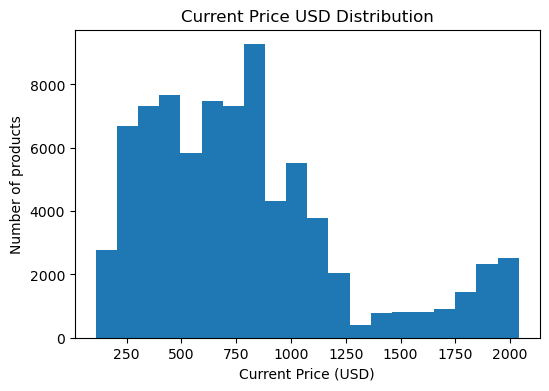

In [12]:
plt.figure(figsize=(6,4))
plt.hist(df["Current_Price_USD"],bins=20)
plt.title("Current Price USD Distribution")
plt.xlabel("Current Price (USD)")
plt.ylabel("Number of products")
plt.show()

### Observation
- Most apple products have a current price between 300 USD nad 1100 USD
- There are fewer premium products between 1500 USD and 2100 USD
- The distribution is right-skewed indicating that high-priced products are less common 

### Segment analysis by Product category and Stock status

In [13]:
df.groupby("Product_Category")[["Launch_Price_USD", "Current_Price_USD"]].mean().round(2)

,Launch_Price_USD,Current_Price_USD
Product_Category,,
Mac,1612.31,1382.49
Watch,533.32,398.64
iPad,749.82,573.08
iPhone,940.69,758.67


In [14]:
df.groupby("Stock_Status")[["Launch_Price_USD", "Current_Price_USD"]].mean().round(2)

,Launch_Price_USD,Current_Price_USD
Stock_Status,,
In Stock,978.23,819.92
Low Stock,934.54,708.52
Out of Stock,930.77,694.37


### Derive Date features

In [15]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Quarter"] =df["Date"].dt.quarter
df["Day"] = df["Date"].dt.day
df["Day_Name"] = df["Date"].dt.day_name()

In [16]:
df[["Date", "Year", "Month", "Month_Name", "Quarter", "Day", "Day_Name"]].head()

,Date,Year,Month,Month_Name,Quarter,Day,Day_Name
0,2020-09-19,2020,9,September,3,19,Saturday
1,2020-09-20,2020,9,September,3,20,Sunday
2,2020-09-23,2020,9,September,3,23,Wednesday
3,2020-09-23,2020,9,September,3,23,Wednesday
4,2020-09-24,2020,9,September,3,24,Thursday


In [17]:
df.to_csv("cleaned_and_updated_apple_products_pricing.csv", index = False)

In [18]:
print("Dataset updated successfully")

Dataset updated successfully


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv("cleaned_and_updated_apple_products_pricing.csv")

In [21]:
df.head()

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count,Year,Month,Month_Name,Quarter,Day,Day_Name
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.41,0.0,No_Sale_Event,In Stock,4.7,40,2020,9,September,3,19,Saturday
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.43,0.0,No_Sale_Event,Out of Stock,4.6,84,2020,9,September,3,20,Sunday
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.36,1.5,No_Sale_Event,In Stock,4.4,110,2020,9,September,3,23,Wednesday
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.70,0.9,No_Sale_Event,In Stock,4.8,111,2020,9,September,3,23,Wednesday
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.28,0.0,No_Sale_Event,In Stock,4.7,35,2020,9,September,3,24,Thursday


## Outliers analysis

In [22]:
import pandas as pd
import numpy as np
import matplotlib .pyplot as plt
import seaborn as sns

df= pd.read_csv("cleaned_and_updated_apple_products_pricing.csv")

In [23]:
df.columns

Index(['Date', 'Platform', 'Product_Category', 'Model_Name', 'Condition',
       'Launch_Price_USD', 'Launch_Price_INR', 'Current_Price_USD',
       'Current_Price_INR', 'Discount_Pct', 'Sale_Event', 'Stock_Status',
       'Rating', 'Reviews_Count', 'Year', 'Month', 'Month_Name', 'Quarter',
       'Day', 'Day_Name'],
      dtype='object')

In [24]:
price_cols=['Launch_Price_USD','Launch_Price_INR','Current_Price_USD']
df[price_cols].describe()

,Launch_Price_USD,Launch_Price_INR,Current_Price_USD
count,80000.000000,80000.000000,80000.000000
mean,963.959125,94467.994250,782.769855
std,470.086413,46068.468464,461.673970
min,329.000000,32242.000000,109.930000
25%,599.000000,58702.000000,432.930000
50%,799.000000,78302.000000,699.740000
75%,1199.000000,117502.000000,989.112500
max,1999.000000,195902.000000,2038.970000


### IQR Outlier Analysis

#### Launch_Price_USD (Outliers)

In [25]:
Q1 = df["Launch_Price_USD"].quantile(0.25)
Q3 = df["Launch_Price_INR"].quantile(0.75)

IQR = Q3-Q1

lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
print("Lower_limit:", lower_limit)
print("Upper_limit:", upper_limit)



Lower_limit: -174755.5
Upper_limit: 292856.5


In [26]:
outliers = df[df["Launch_Price_USD"] > 292856.5]
outliers

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count,Year,Month,Month_Name,Quarter,Day,Day_Name


In [27]:
outliers.shape[0]

0

In [28]:
outliers = df[
    (df['Launch_Price_USD'] < lower_limit) |
    (df['Launch_Price_USD'] > upper_limit)
]

outliers.head()

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count,Year,Month,Month_Name,Quarter,Day,Day_Name


In [29]:
len(outliers)

0

#### Launch_Price_INR (Outliers)

In [30]:
Q1 = df["Launch_Price_INR"].quantile(0.25)
Q3 = df["Launch_Price_INR"].quantile(0.75)

IQR = Q3-Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower_limit:", lower_limit)
print("Upper_limit:", upper_limit)


Lower_limit: -29498.0
Upper_limit: 205702.0


In [31]:
outliers = df[
    (df['Launch_Price_INR'] < lower_limit) |
    (df['Launch_Price_INR'] > upper_limit)
]


In [32]:
outliers

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count,Year,Month,Month_Name,Quarter,Day,Day_Name


In [33]:
len(outliers)

0

#### Current_price_USD(Outliers)

In [34]:
Q1 = df["Current_Price_USD"].quantile(0.25)
Q3 = df["Current_Price_USD"].quantile(0.75)

IQR = Q3-Q1

lower_limit = Q1 - 1.5* IQR
upper_limit = Q3 + 1.5 *IQR
print("Lower_limit:", lower_limit)
print("Upper_limit:", upper_limit)


Lower_limit: -401.34374999999983
Upper_limit: 1823.3862499999998


In [35]:
outliers = df[
    (df['Current_Price_USD'] < lower_limit) |
    (df['Current_Price_USD'] > upper_limit)
]


In [36]:
outliers

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count,Year,Month,Month_Name,Quarter,Day,Day_Name
2752,2021-10-26,Amazon,Mac,MacBook Pro 14-inch M1 Pro 512GB,New,1999,195902,1989.18,191811.31,0.5,No_Sale_Event,In Stock,4.3,43,2021,10,October,4,26,Tuesday
2768,2021-10-27,Amazon,Mac,MacBook Pro 14-inch M1 Pro 512GB,New,1999,195902,2024.86,201607.17,0.0,No_Sale_Event,In Stock,4.6,25,2021,10,October,4,27,Wednesday
2769,2021-10-27,Amazon,Mac,MacBook Pro 14-inch M1 Pro 512GB,New,1999,195902,1959.26,193204.57,2.0,No_Sale_Event,In Stock,4.5,51,2021,10,October,4,27,Wednesday
2800,2021-10-29,Amazon,Mac,MacBook Pro 14-inch M1 Pro 512GB,New,1999,195902,1980.15,197218.05,0.9,No_Sale_Event,In Stock,4.2,66,2021,10,October,4,29,Friday
2818,2021-10-30,Amazon,Mac,MacBook Pro 14-inch M1 Pro 512GB,New,1999,195902,1967.52,196577.01,1.6,No_Sale_Event,In Stock,4.8,78,2021,10,October,4,30,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79877,2026-07-30,Amazon,Mac,MacBook Pro 14-inch M4 Pro 512GB,New,1999,195902,1895.71,189232.58,5.2,No_Sale_Event,In Stock,4.5,964,2026,7,July,3,30,Thursday
79878,2026-07-30,Amazon,Mac,MacBook Pro 14-inch M4 Pro 512GB,New,1999,195902,1936.27,193159.56,3.1,No_Sale_Event,In Stock,4.4,3430,2026,7,July,3,30,Thursday
79952,2026-07-31,Flipkart,Mac,MacBook Pro 14-inch M4 Pro 512GB,New,1999,195902,1913.92,190679.41,4.3,No_Sale_Event,In Stock,4.5,3166,2026,7,July,3,31,Friday
79953,2026-07-31,Flipkart,Mac,MacBook Pro 14-inch M4 Pro 512GB,New,1999,195902,1870.03,184162.22,6.5,No_Sale_Event,In Stock,4.7,2349,2026,7,July,3,31,Friday


In [37]:
df.drop(['Year', 'Month', 'Month_Name', 'Quarter',
       'Day', 'Day_Name'],axis = 1,inplace = True)

In [38]:
df.columns

Index(['Date', 'Platform', 'Product_Category', 'Model_Name', 'Condition',
       'Launch_Price_USD', 'Launch_Price_INR', 'Current_Price_USD',
       'Current_Price_INR', 'Discount_Pct', 'Sale_Event', 'Stock_Status',
       'Rating', 'Reviews_Count'],
      dtype='object')

#### Calculating zscore

In [39]:
from scipy.stats import zscore

In [40]:
price_cols = [
    'Launch_Price_USD',
    'Launch_Price_INR',
    'Current_Price_USD'
]

for col in price_cols:
    df[col + '_zscore'] = zscore(df[col])

In [41]:
for col in price_cols : 
    outliers = df[abs(df[col + '_zscore'])>3]

In [42]:
print(col,"outliers:",outliers.shape[0])

Current_Price_USD outliers: 0


## Data visualization charts

#### 1. Distribution chart

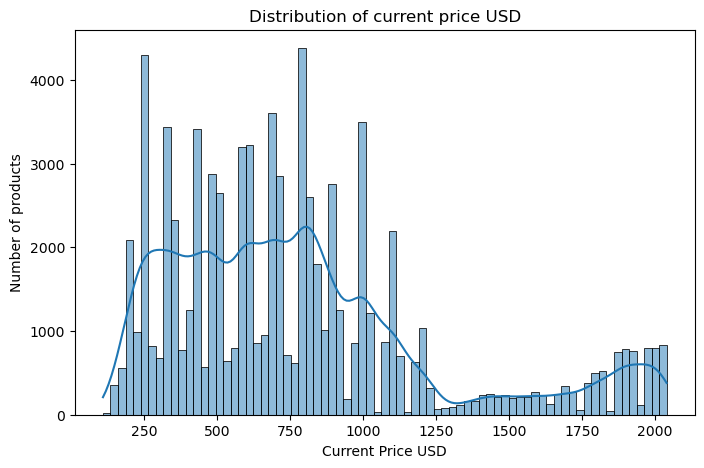

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize =(8,5))

sns.histplot(
    df["Current_Price_USD"],
    kde =True
)
plt.title("Distribution of current price USD")
plt.xlabel("Current Price USD")
plt.ylabel("Number of products")
plt.show()



#### 2. Trend chart

In [51]:
df["Date"]=pd.to_datetime(df["Date"])

In [52]:
df['Year'] =df['Date'].dt.year

In [53]:
df.columns

Index(['Date', 'Platform', 'Product_Category', 'Model_Name', 'Condition',
       'Launch_Price_USD', 'Launch_Price_INR', 'Current_Price_USD',
       'Current_Price_INR', 'Discount_Pct', 'Sale_Event', 'Stock_Status',
       'Rating', 'Reviews_Count', 'Launch_Price_USD_zscore',
       'Launch_Price_INR_zscore', 'Current_Price_USD_zscore', 'Year'],
      dtype='object')

Text(0, 0.5, 'Average launch price USD')

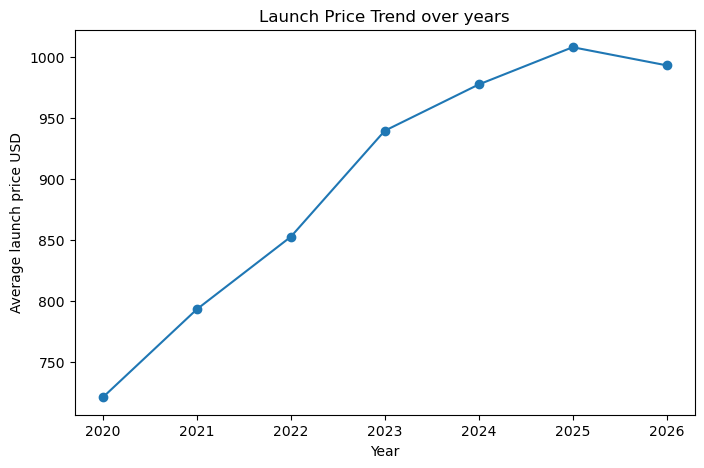

In [56]:
year_price = df.groupby('Year')['Launch_Price_USD'].mean()

year_price.plot(
    kind = 'line',
    marker = 'o',
    figsize = (8,5)
)        
plt.title("Launch Price Trend over years")
plt.xlabel("Year")
plt.ylabel("Average launch price USD")    
    
    

#### 3. Comparison chart

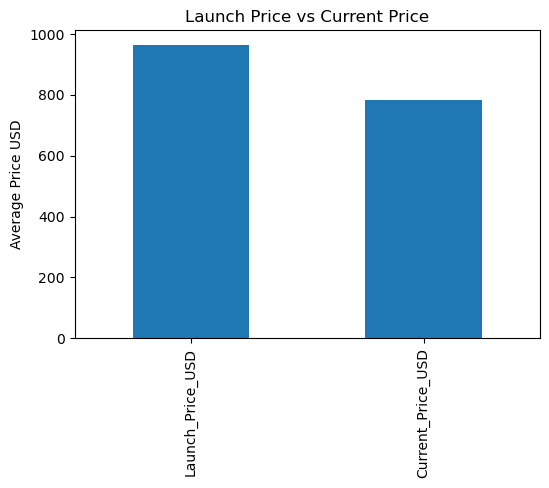

In [61]:
price_compare = df[
['Launch_Price_USD','Current_Price_USD']
].mean()

price_compare.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Launch Price vs Current Price")
plt.ylabel("Average Price USD")

plt.show()

#### 4. Composition chart (Pie chart)

In [65]:
category = df["Product_Category"].value_counts()

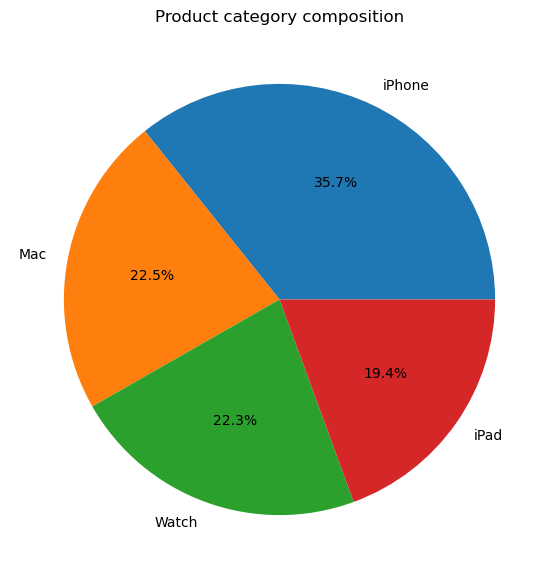

In [68]:
plt.figure(figsize =(7,7))
plt.pie(category,
        labels = category.index,
        autopct = '%1.1f%%')
plt.title("Product category composition")
plt.show()


### 5 - databased Insights
- Launch price USD is higher than Current price USD on average,indicating that Apple product prices generally decrease after launch.
- Current price USD values are concentrated in a specific price range ,with fewer products at very high prices.
- IQR analysis found no outliers in Launch price USD and Launch price INR, showing consistent launch pricing.
- Current price USD shows outliers with the IQR method ,representing premium-priced Apple products ,while the Zscore analysis did not detect statistically extreme values.
- The charts show clear differences in pricing across products and categories, helping to understand Apple products pricing patterns.